In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Add, Multiply, Activation, Reshape, Flatten
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [3]:
import albumentations as A

# Data processing
img_data_list = []
labels = []

# Define augmentation techniques
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.2)
])

# Function to process and augment images
def process_images(data_path, label, save_path, num_aug=3):
    os.makedirs(save_path, exist_ok=True)  # Create folder for augmented images

    for dataset in os.listdir(data_path):
        img_path = os.path.join(data_path, dataset)
        input_img = cv2.imread(img_path)

        if input_img is None:
            print(f"Warning: Image {dataset} could not be loaded.")
            continue

        input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
        input_img_resize = cv2.resize(input_img, (224, 224))
        input_img_resize = cv2.normalize(input_img_resize, None, 0, 255, cv2.NORM_MINMAX)

        # Add original image to dataset
        img_data_list.append(input_img_resize)
        labels.append(label)

        # Augment and add multiple versions
        for i in range(num_aug):
            augmented = transform(image=input_img_resize)['image']
            img_data_list.append(augmented)  # Add augmented image
            labels.append(label)  # Keep same label

            # Save augmented image
            aug_filename = f"aug_{i}_{dataset}"
            cv2.imwrite(os.path.join(save_path, aug_filename), cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))

# Load and augment data for each class
process_images('/content/drive/MyDrive/major-project/OS Collected Data/Normal folder/0', 0,
               '/content/drive/MyDrive/major-project/OS Collected Data/Normal folder/0_Augmented')

process_images('/content/drive/MyDrive/major-project/OS Collected Data/Osteopenia folder/1', 1,
               '/content/drive/MyDrive/major-project/OS Collected Data/Osteopenia folder/1_Augmented')

process_images('/content/drive/MyDrive/major-project/OS Collected Data/Osteoporosis folder/2', 2,
               '/content/drive/MyDrive/major-project/OS Collected Data/Osteoporosis folder/2_Augmented')

In [4]:
print(f"Total images in dataset: {len(img_data_list)}")
print(f"Total labels in dataset: {len(labels)}")

# Optional: Count images per class
unique_labels, counts = np.unique(labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"Class {label}: {count} images")


Total images in dataset: 7788
Total labels in dataset: 7788
Class 0: 3120 images
Class 1: 1496 images
Class 2: 3172 images


In [5]:
# from keras.utils import np_utils
from keras.utils import to_categorical
num_classes = 3
label = to_categorical(labels, num_classes)

In [6]:
# Convert lists to arrays
img_data = np.array(img_data_list)
labels = np.array(labels)

print(f'Image data shape: {img_data.shape}')
print(f'Labels shape: {labels.shape}')


Image data shape: (7788, 224, 224, 3)
Labels shape: (7788,)


In [7]:
# import cv2
# import os

# image_folder = "path/to/your/images"
# image_list = []

# for filename in os.listdir(image_folder):
#     file_path = os.path.join(image_folder, filename)
#     image = cv2.imread(file_path)

#     if image is None:
#         print(f"Could not read image: {file_path}")
#     else:
#         image_list.append(image)
#         print(f"Added: {file_path}")

# print(f"Total images added: {len(image_list)}")


In [8]:
print(len(img_data))  # Should be > 0
print(len(label))  # Should be > 0


7788
7788


In [ ]:
# # One-hot encode the labels
# labels = to_categorical(labels, num_classes=3)

In [ ]:
# print(f'Labels shape after one-hot encoding: {labels.shape}')

In [9]:
x_train, x_test, y_train, y_test = train_test_split(img_data, label, test_size=0.1)
# x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.2)

# Print the train set
print('Train Set')
print(x_train.shape)
print(y_train.shape)

# Print the validation set
# print('Validation Set')
# print(x_val.shape)
# print(y_val.shape)

# Print the test set
print('Test Set')
print(x_test.shape)
print(y_test.shape)

Train Set
(7009, 224, 224, 3)
(7009, 3)
Test Set
(779, 224, 224, 3)
(779, 3)


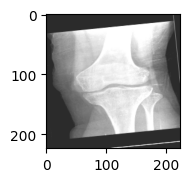

In [10]:
plt.figure(figsize=(8, 8))
for i in range(1, 2):
  plt.subplot(4, 4, i)
  img= x_test[i]
  plt.imshow(img)
plt.show()

In [11]:
import keras
import numpy as np
from keras import models
from keras import layers
from keras import optimizers
import matplotlib.pyplot as plt
from keras.optimizers import SGD, Adam
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, SeparableConv2D,AveragePooling2D,GlobalAveragePooling2D,GlobalMaxPooling2D
import os,cv2
from sklearn.model_selection import train_test_split

In [12]:
def block(inp):
  s1 = SeparableConv2D(filters = 64, kernel_size = (3,3), padding='same', activation='relu')(inp)
  s2 = SeparableConv2D(filters = 32, kernel_size = (3,3), padding='same', activation='relu')(s1)

  return s2

In [13]:
def atten(inp):
  c1 = CA(inp)
  m1 = layers.Multiply()([c1,inp])
  p1 = PA(m1)
  m2 = layers.Multiply()([p1,m1])
  a1 = layers.Add()([inp,m2])

  return a1

In [14]:
def PA(inp):
  c1 = SeparableConv2D(inp[0].shape[2], kernel_size = (3,3), strides = 1, padding = 'same', activation = 'relu')(inp)
  c2 = SeparableConv2D(inp[0].shape[2], kernel_size = (3,3), strides = 1, padding = 'same', activation = 'relu')(inp)
  a1 = layers.Add()([c1,c2,inp])
  c2 = Conv2D(1, kernel_size=(1,1), strides = 1, activation = 'relu')(a1)
  s1 = keras.activations.sigmoid(c2)
  s1 = keras.layers.Reshape((inp[0].shape[0],inp[0].shape[1],1))(s1)
  m1 = layers.Multiply()([s1,inp])
  a2 = layers.Add()([m1,inp])
  # print('PA completed')

  return a2

In [15]:
def CA(inp):
  c1 = Conv2D(32, kernel_size=(3,3), strides = 1, activation = 'relu')(inp)
  # c11 = Conv2D(16, kernel_size=(3,3), strides = 1, activation = 'relu')(c1)
  gmp = GlobalMaxPooling2D()(c1)
  c2 = Conv2D(32, kernel_size=(3,3), strides = 1, activation = 'relu')(inp)
  # c12 = Conv2D(16, kernel_size=(3,3), strides = 1, activation = 'relu')(c2)
  gap = GlobalAveragePooling2D()(c2)
  a1 = layers.Add()([gmp,gap])
  a1 = keras.layers.Reshape((1,1,a1[0].shape[0]))(a1)
  c2 = Conv2D(inp[0].shape[2], kernel_size=(1,1), strides = 1, activation = 'relu')(a1)
  s1 = keras.activations.sigmoid(c2)
  # print('s1',s1.shape)
  # print('inp',inp.shape)
  m1 = layers.Multiply()([s1,inp])
  # print('CA completed')

  return m1

In [16]:
from keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda
from keras import backend as K
from keras.activations import sigmoid
from keras.layers import Flatten, Dense, Input, Conv2D, MaxPooling2D, Dropout, Add, BatchNormalization,Conv1D
import tensorflow as tf
from keras.models import Model

def cbam_block(cbam_feature, ratio=8):
    cbam_feature = channel_attention(cbam_feature, ratio)
    cbam_feature = spatial_attention(cbam_feature)
    return cbam_feature

def channel_attention(input_feature, ratio=8):
    H, W, C = map(int, input_feature.get_shape()[1:])
    channel = C

    shared_layer_one = Dense(channel//ratio,
                             activation='relu',
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')
    shared_layer_two = Dense(channel,
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1,1,channel))(avg_pool)
    #assert avg_pool._keras_shape[1:] == (1,1,channel)
    avg_pool = shared_layer_one(avg_pool)
    #assert avg_pool._keras_shape[1:] == (1,1,channel//ratio)
    avg_pool = shared_layer_two(avg_pool)
    #assert avg_pool._keras_shape[1:] == (1,1,channel)

    max_pool = GlobalMaxPooling2D()(input_feature)
    max_pool = Reshape((1,1,channel))(max_pool)
    #assert max_pool._keras_shape[1:] == (1,1,channel)
    max_pool = shared_layer_one(max_pool)
    #assert max_pool._keras_shape[1:] == (1,1,channel//ratio)
    max_pool = shared_layer_two(max_pool)
    #assert max_pool._keras_shape[1:] == (1,1,channel)

    cbam_feature = Add()([avg_pool,max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return multiply([input_feature, cbam_feature])

def spatial_attention(input_feature):
    kernel_size = 7
    H, W, C = map(int, input_feature.get_shape()[1:])
    if K.image_data_format() == "channels_first":
        channel = C
        cbam_feature = Permute((2,3,1))(input_feature)
    else:
        channel = C
        cbam_feature = input_feature

    avg_pool = Lambda(lambda x: K.mean(x, axis=3, keepdims=True))(cbam_feature)
    #assert avg_pool._keras_shape[-1] == 1
    max_pool = Lambda(lambda x: K.max(x, axis=3, keepdims=True))(cbam_feature)
    #assert max_pool._keras_shape[-1] == 1
    concat = Concatenate(axis=3)([avg_pool, max_pool])
    #assert concat._keras_shape[-1] == 2
    cbam_feature = Conv2D(filters = 1,
                    kernel_size=kernel_size,
                    strides=1,
                    padding='same',
                    activation='sigmoid',
                    kernel_initializer='he_normal',
                    use_bias=False)(concat)
    #assert cbam_feature._keras_shape[-1] == 1

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return multiply([input_feature, cbam_feature])

In [17]:
#create the input layer
input_layer = Input(shape=(x_train[0].shape))

c1 = Conv2D(32, kernel_size=(3,3), strides = 1, activation = 'relu')(input_layer)

b1 = block(c1)
a1 = atten(b1)

b2 = block(b1)
a2 = atten(b2)

b3 = block(b2)
a3 = atten(b3)

# b4 = block(b3)
# a4 = atten(b4)

# t1 = layers.Conv2DTranspose(32, kernel_size=3, strides=1, padding='same')(a4)
# cat1 = layers.Concatenate(axis=3)([a3,t1])
# c2 = Conv2D(16, kernel_size=(3,3), strides = 1, padding='same', activation = 'relu')(cat1)

t1 = layers.Conv2DTranspose(32, kernel_size=3, strides=1, padding='same')(a3)  #(c2)
cat1 = layers.Concatenate(axis=3)([a2,t1])
c2 = Conv2D(16, kernel_size=(3,3), strides = 1, padding='same', activation = 'relu')(cat1)

t1 = layers.Conv2DTranspose(32, kernel_size=3, strides=1, padding='same')(c2)
cat1 = layers.Concatenate(axis=3)([a1,t1])
c2 = Conv2D(16, kernel_size=(3,3), strides = 1, activation = 'relu')(cat1)

f1 = Flatten()(c2)
# g1 = GlobalMaxPooling2D()(c2)
d1 = Dense(128, activation='softmax')(f1)
output = Dense(3, activation='softmax')(d1)


model = Model(inputs=input_layer, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 222, 222, 32)   │            896 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d          │ (None, 222, 222, 64)   │          2,400 │ conv2d[0][0]           │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_1        │ (None, 222, 222, 32)   │          2,656 │ separable_conv2d[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_4        │ (None, 222, 222, 64)   │          2,400 │ separable_conv2d_1[0]… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_5        │ (None, 222, 222, 32)   │          2,656 │ separable_conv2d_4[0]… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_8        │ (None, 222, 222, 64)   │          2,400 │ separable_conv2d_5[0]… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_9        │ (None, 222, 222, 32)   │          2,656 │ separable_conv2d_8[0]… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 220, 220, 32)   │          9,248 │ separable_conv2d_9[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 220, 220, 32)   │          9,248 │ separable_conv2d_9[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 220, 220, 32)   │          9,248 │ separable_conv2d_5[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 220, 220, 32)   │          9,248 │ separable_conv2d_5[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling2d_2    │ (None, 32)             │              0 │ conv2d_9[0][0]         │
│ (GlobalMaxPooling2D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 32)             │              0 │ conv2d_10[0][0]        │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling2d_1    │ (None, 32)             │              0 │ conv2d_5[0][0]         │
│ (GlobalMaxPooling2D)      │                        │                │                        │
├──────────────────────

 Total params: 99,238,950 (378.57 MB)

 Trainable params: 99,238,950 (378.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras import optimizers as optim
from keras import backend as K
from keras import optimizers

model.compile(loss='categorical_crossentropy',optimizer = Adam(learning_rate=0.0001),metrics=['accuracy'])
# Train the model
history = model.fit(x_train, y_train, epochs=80, batch_size=16, validation_data=(x_test, y_test), verbose=1)


Epoch 1/80
439/439 ━━━━━━━━━━━━━━━━━━━━ 253s 498ms/step - accuracy: 0.4202 - loss: 1.0577 - val_accuracy: 0.5032 - val_loss: 1.0560
Epoch 2/80
439/439 ━━━━━━━━━━━━━━━━━━━━ 223s 463ms/step - accuracy: 0.5043 - loss: 1.0482 - val_accuracy: 0.5327 - val_loss: 1.0245
Epoch 3/80
439/439 ━━━━━━━━━━━━━━━━━━━━ 256s 450ms/step - accuracy: 0.5234 - loss: 1.0193 - val_accuracy: 0.5725 - val_loss: 0.9970
Epoch 4/80
439/439 ━━━━━━━━━━━━━━━━━━━━ 201s 449ms/step - accuracy: 0.5342 - loss: 1.0016 - val_accuracy: 0.5623 - val_loss: 0.9859
Epoch 5/80
439/439 ━━━━━━━━━━━━━━━━━━━━ 207s 461ms/step - accuracy: 0.5364 - loss: 0.9953 - val_accuracy: 0.5648 - val_loss: 0.9842
Epoch 6/80
439/439 ━━━━━━━━━━━━━━━━━━━━ 257s 450ms/step - accuracy: 0.5511 - loss: 0.9830 - val_accuracy: 0.4454 - val_loss: 1.0062
Epoch 7/80
439/439 ━━━━━━━━━━━━━━━━━━━━ 202s 450ms/step - accuracy: 0.4258 - loss: 1.0161 - val_accuracy: 0.4506 - val_loss: 1.0345
Epoch 8/80
439/439 ━━━━━━━━━━━━━━━━━━━━ 201s 449ms/step - accuracy: 0.4353 -